In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import pandas as pd
import scarf
from scarf.agent import analyze_rna

scarf.configure_output(level="WARNING", progress=False)
source_path = scarf.cytebase.connect("scarf_docs").download(
    "tenx_5K_pbmc_rnaseq/data.h5", destination="scarf_datasets",
)[0]
teaching_directory = TemporaryDirectory(prefix="scarf-agent-teaching-")
zarr_path = Path(teaching_directory.name) / "analysis.zarr"
study_context = (
    "Human 10x Genomics 5K PBMC 3-prime gene expression from peripheral blood, "
    "collected from one healthy donor. No treatment comparison, trusted technical "
    "batch column, paired modality, or independent replication metadata is available. "
    "Do not invent missing design variables or report treatment effects."
)
source_path.name

Downloading bucket files: 18098007 / 18098007 complete

Downloading bytes: 18098007 / 18098007 complete

'data.h5'

In [2]:
import json
from typing import Any

from IPython import get_ipython
from pydantic_ai.messages import (
    ModelMessage,
    ModelResponse,
    ToolCallPart,
    ToolReturnPart,
)
from pydantic_ai.models.function import AgentInfo, FunctionModel

from scarf.agent.data_enrichment import (
    AssayFeatureInspectionBatch,
    DataEnrichmentReport,
    FeatureSelectionPolicy,
    StudyContextSummary,
)
from scarf.agent.experimental_context import (
    BatchCorrectionPlan,
    CovariateEvidence,
    ExperimentalContextDecision,
)

notebook_shell = get_ipython()
if notebook_shell is not None:
    notebook_shell.run_line_magic("matplotlib", "inline")

def _prompt_text(messages: list[ModelMessage]) -> str:
    values = []
    for message in messages:
        for part in message.parts:
            content = getattr(part, "content", None)
            if isinstance(content, str):
                values.append(content)
            elif isinstance(content, tuple):
                values.extend(item for item in content if isinstance(item, str))
    return "\n".join(values)


def _tool_result(
    messages: list[ModelMessage],
    tool_name: str,
    model_type: Any,
) -> Any:
    for message in reversed(messages):
        for part in reversed(message.parts):
            if isinstance(part, ToolReturnPart) and part.tool_name == tool_name:
                if isinstance(part.content, model_type):
                    return part.content
                if isinstance(part.content, str):
                    return model_type.model_validate_json(part.content)
                return model_type.model_validate(part.content)
    raise AssertionError(f"Missing tool return {tool_name!r}")


def _tool_call(name: str, args: dict[str, Any] | None = None) -> ModelResponse:
    return ModelResponse(parts=[ToolCallPart(tool_name=name, args=args or {})])


def _structured_output(info: AgentInfo, value: Any) -> ModelResponse:
    payload = value.model_dump() if hasattr(value, "model_dump") else value
    return _tool_call(info.output_tools[0].name, payload)


def _scripted_workflow_model() -> tuple[FunctionModel, dict[str, Any]]:
    state = {
        "enrichment": 0,
        "context": 0,
        "parameter": 0,
        "assessments": [],
        "requests": 0,
    }

    async def reply(
        messages: list[ModelMessage],
        info: AgentInfo,
    ) -> ModelResponse:
        state["requests"] += 1
        tools = {tool.name for tool in info.function_tools}

        if (
            "inspect_assay_features_batch" in tools
            or state["enrichment"] == 1
            or any(
                tool.parameters_json_schema.get("title") == "DataEnrichmentReport"
                for tool in info.output_tools
            )
        ):
            if state["enrichment"] == 0:
                state["enrichment"] = 1
                return _tool_call("inspect_assay_features_batch")

            batch = _tool_result(
                messages,
                "inspect_assay_features_batch",
                AssayFeatureInspectionBatch,
            )
            policies = []
            for inspection in batch.inspections:
                species_observed = inspection.species != "unknown"
                policy_evidence = list(inspection.evidenceIds)
                if not species_observed:
                    policy_evidence.append("context:study")
                policies.append(
                    FeatureSelectionPolicy(
                        assay=inspection.assay,
                        species=(
                            inspection.species
                            if species_observed
                            else "homo_sapiens"
                        ),
                        speciesConfidence="high" if species_observed else "medium",
                        speciesRationale=(
                            inspection.speciesReason
                            or "The exact study paragraph identifies a human sample."
                        ),
                        excludeFamilies=[
                            family.family
                            for family in inspection.families
                            if family.count > 0 and family.defaultExclude is True
                        ],
                        protectFamilies=[
                            family.family
                            for family in inspection.families
                            if family.count > 0 and family.defaultExclude is False
                        ],
                        rationale=(
                            "Exclude observed technical families and preserve "
                            "observed protected families."
                        ),
                        evidenceIds=list(dict.fromkeys(policy_evidence)),
                    )
                )
            state["enrichment"] = 2
            return _structured_output(
                info,
                DataEnrichmentReport(
                    status="done",
                    studyContextSummary=StudyContextSummary(
                        organismReferences=["Human"],
                        tissueReferences=["peripheral blood"],
                        experimentalReferences=[
                            "10x Genomics 5K PBMC 3-prime gene expression"
                        ],
                        analysisIntentReferences=[
                            "Discover stable major immune-cell populations."
                        ],
                    ),
                    policies=policies,
                ),
            )

        if tools.intersection(
            {
                "inspect_cell_covariates",
                "analyze_experimental_design",
                "score_current_representation",
            }
        ) or state["context"] in {1, 2} or any(
            tool.parameters_json_schema.get("title") == "ExperimentalContextDecision"
            for tool in info.output_tools
        ):
            if state["context"] == 0:
                state["context"] = 1
                return _tool_call("inspect_cell_covariates")
            if state["context"] == 1:
                state["context"] = 2
                return _tool_call(
                    "analyze_experimental_design",
                    {
                        "column_domains": {},
                        "coefficients_of_interest": [],
                        "units_of_inference": {},
                        "batch_columns": [],
                    },
                )

            design = _tool_result(
                messages,
                "analyze_experimental_design",
                CovariateEvidence,
            )
            profile = next(
                value
                for value in design.qcProfiles
                if value.action == "skip"
            )
            evidence_id = profile.evidenceId
            state["context"] = 3
            return _structured_output(
                info,
                ExperimentalContextDecision(
                    batchCorrection=BatchCorrectionPlan(
                        action="skip",
                        rationale="No trusted technical batch column was supplied.",
                        evidenceIds=[evidence_id],
                    ),
                    rationale="No experimental covariates were supplied.",
                    evidenceIds=[evidence_id],
                ),
            )

        prompt = _prompt_text(messages)
        if any(
            tool.parameters_json_schema.get("title") == "TuningAction"
            for tool in info.output_tools
        ):
            evidence, _ = json.JSONDecoder().raw_decode(prompt[prompt.index("{") :])
            candidates = [
                item for item in evidence["candidates"]
                if item["status"] == "done" and item["eligible"]
            ]
            if not candidates:
                raise AssertionError("The teaching run has no supported partition")

            def measured(item, name):
                value = item["metrics"].get(name)
                return float(value) if value is not None else 0.0

            selected = max(
                candidates,
                key=lambda item: (
                    measured(item, "seedStability"),
                    measured(item, "markerCoherence"),
                ),
            )
            metrics = selected["metrics"]
            genes = list(dict.fromkeys(
                gene for names in metrics.get("topMarkerGenes", {}).values()
                for gene in names
            ))[:8]
            quantitative = (
                f"Compared {len(candidates)} observed partitions; selected resolution "
                f"{selected['parameters']['leidenResolution']}, with seed stability "
                f"{metrics.get('seedStability')} and marker coherence "
                f"{metrics.get('markerCoherence')}."
            )
            qualitative = (
                "The saved marker preview contains " + ", ".join(genes) + "."
                if genes else "The saved marker preview is empty; cell identities remain unresolved."
            )
            action = {
                "action": "accept",
                "selectedCandidateId": selected["candidateId"],
                "correctionNeed": "notApplicable",
                "assessedDomains": evidence["assessedDomains"],
                "evidenceIds": [
                    f"candidate:{selected['candidateId']}",
                    *list(evidence["imageHashes"])[:1],
                    "studyContract", "qcPolicy", "samplingCoverage", "featureEvidence",
                ],
                "quantitativeFindings": [quantitative],
                "qualitativeFindings": [qualitative],
                "objectivePreservation": (
                    "Preserve the single-donor population structure and retain marker "
                    "uncertainty; no batch or treatment comparison is supported."
                ),
                "rationale": (
                    "The teaching policy selects the observed partition with the "
                    "greatest seed stability, using marker coherence to break ties. "
                    + quantitative
                ),
            }
            state["assessments"].append({
                "selection": action,
                "alternatives": [{
                    "resolution": item["parameters"]["leidenResolution"],
                    "clusters": item["metrics"].get("nClusters"),
                    "seed_stability": item["metrics"].get("seedStability"),
                    "marker_coherence": item["metrics"].get("markerCoherence"),
                    "selected": item["candidateId"] == selected["candidateId"],
                } for item in candidates],
            })
            return _structured_output(info, action)

        payload, _ = json.JSONDecoder().raw_decode(prompt[prompt.index("{") :])
        decision = payload["spec"]
        evidence_by_class = {}
        evidence_class_by_id = {}
        for item in payload["evidence"]["evidence"]:
            evidence_by_class.setdefault(
                item["evidenceClass"],
                item["evidenceId"],
            )
            evidence_class_by_id[item["evidenceId"]] = item["evidenceClass"]
        preferred = decision.get("metricPreferredOptionId")
        selected = (
            next(
                option
                for option in decision["options"]
                if option["optionId"] == preferred
            )
            if preferred is not None
            else next(
                option
                for option in decision["options"]
                if option["status"] in {"apply", "skip"}
            )
        )
        evidence_ids = list(selected.get("requiredEvidenceIds", []))
        cited_classes = {
            evidence_class_by_id[evidence_id] for evidence_id in evidence_ids
        }
        for evidence_class in selected["requiredEvidenceClasses"]:
            if evidence_class not in cited_classes:
                evidence_ids.append(evidence_by_class[evidence_class])
        state["parameter"] += 1
        return _structured_output(
            info,
            dict(
                selectedOptionId=selected["optionId"],
                evidenceIds=evidence_ids,
                rationale=f"Use the offered {selected['label']} policy with its required observed evidence.",
                confidence="high",
            ),
        )

    return FunctionModel(reply), state

In [3]:
model, model_state = _scripted_workflow_model()
result = analyze_rna(
    source_path,
    model=model,
    study_context=study_context,
    study_objective="Discover stable major immune-cell populations.",
    zarr_path=zarr_path,
)
{"status": result.status}

{'status': 'completed'}

In [4]:
assessment = model_state["assessments"][-1]
pd.DataFrame(assessment["alternatives"])

,resolution,clusters,seed_stability,marker_coherence,selected
0,0.50,11,0.931020,1.000000,True
1,0.75,14,0.841935,1.000000,False
2,1.00,14,0.721669,1.000000,False
3,1.25,18,0.804343,0.833333,False


In [5]:
selection = assessment["selection"]
{
    "why": selection["rationale"],
    "marker_evidence": selection["qualitativeFindings"],
    "biology_to_preserve": selection["objectivePreservation"],
}

{'why': 'The teaching policy selects the observed partition with the greatest seed stability, using marker coherence to break ties. Compared 4 observed partitions; selected resolution 0.5, with seed stability 0.9310201021058004 and marker coherence 1.0.',
 'marker_evidence': ['The saved marker preview contains ALDH1A1, VCAN, CD163, S100A12, QPCT, CLEC4E, CD14, CYP27A1.'],
 'biology_to_preserve': 'Preserve the single-donor population structure and retain marker uncertainty; no batch or treatment comparison is supported.'}

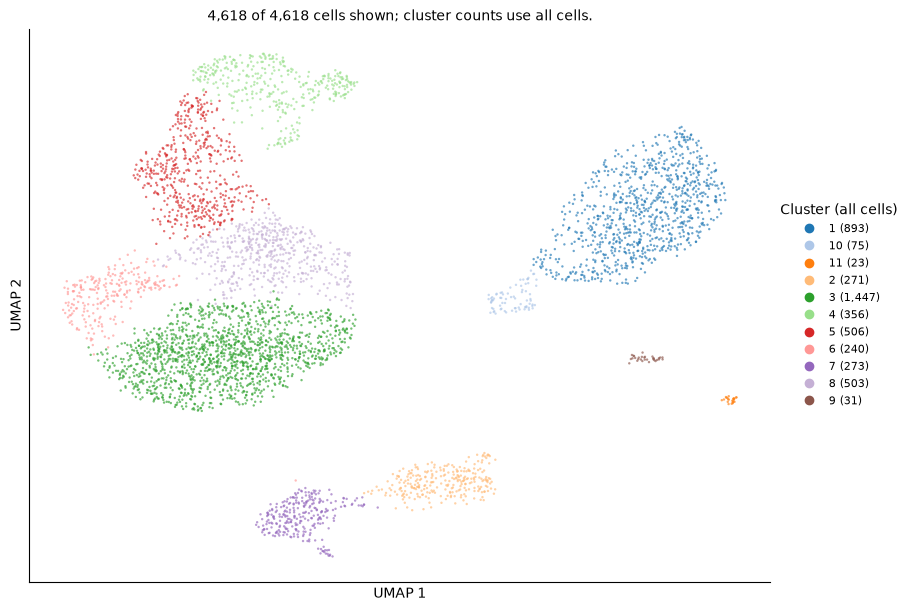

In [6]:
result.plot_embedding(figsize=(9, 6))

In [7]:
marker_table = result.get_markers()
marker_table.sort_values(
    ["group_id", "score"], ascending=[True, False],
).groupby("group_id", sort=True).head(2)[
    ["group_id", "feature_name", "score", "frac_exp"]
].head(12)

,group_id,feature_name,score,frac_exp
0,1,ALDH1A1,0.90473,0.49496
1,1,VCAN,0.90104,0.98096
535,10,CTSL,0.77585,0.78667
536,10,C1QA,0.73980,0.52000
974,11,SERPINF1,0.84146,0.91304
975,11,LILRA4,0.83217,1.00000
1530,2,TNFRSF13B,0.83873,0.71956
1531,2,IGHA1,0.82460,0.71956
1633,3,LRRN3,0.72325,0.54112
1634,3,NOG,0.59662,0.26399


In [8]:
report_path = result.report()
{"report": report_path.name, "exists": report_path.is_file()}

{'report': 'index.html', 'exists': True}